# Phase 1 – Supervised Learning
## Credit Card Fraud Detection

 | Name | Role / Task |
|-----------|----------------|
| Khawlah Alawadi | Algorithm Selection & Implementation |
| Aleen Alqasem | Algorithm Selection & Implementation |
|  Fatima Alsaggaf  | Algorithm Selection & Implementation |
| Ruba Fayez   | Model Comparison & Analysis
 |
## **Table of Contents**

1.  [Model Selection Rationale](#1-model-selection-rationale)
2.  [Data Preparation](#2-data-preparation)
3.  [Feature Scaling and Handling Class Imbalance](#3-feature-scaling-and-handling-class-imbalance)
4.  [Model Training and Optimization Strategy](#4-model-training--optimization-strategy)
    * [4.1 Logistic Regression Implementation & Tuning](#41-logistic-regression-implementation--tuning)
    * [4.2 Random Forest Implementation & Tuning](#42-random-forest-implementation--tuning)
    * [4.3 XGBoost Implementation & Manual Tuning](#43-xgboost-implementation--manual-tuning)
5.  [Model Stability Check (K-Fold Cross-Validation)](#5-model-stability-check-k-fold-cross-validation)
6.  [Evaluation Metrics and Visualization](#6-evaluation-metrics-and-visualization)
7.  [Feature Importance Analysis](#7-feature-importance-analysis)
8.  [Model Comparison & Analysis](#8-model-comparison--analysis)
9.  [Best Model Selection & Reasoning](#9-best-model-selection--reasoning)
10. [Next Steps for Phase 2 Integration](#10-next-steps-for-phase-2-integration)
11. [References](#11-references)



This notebook presents the supervised learning phase of our project, which focuses on detecting fraudulent credit card transactions using machine learning techniques.

The objective of this phase is to build, train, and evaluate multiple supervised learning models in order to identify fraudulent transactions accurately. Fraud detection is a challenging problem because fraudulent transactions represent only a very small portion of the dataset, which creates a strong class imbalance.

To address this problem, we implemented and compared three different supervised learning algorithms:

- Logistic Regression
- Random Forest
- XGBoost

By experimenting with multiple algorithms, we aim to determine which model provides the strongest balance between accuracy, recall, precision, and overall reliability in detecting fraud , also establishes the basis for model comparison and final model selection.

# Model Selection Rationale

In this project, three supervised learning algorithms were selected to represent different machine learning approaches and to provide a meaningful comparison for fraud detection.

## Logistic Regression

Logistic Regression was selected as a baseline model for binary classification. Since our target variable has two classes (fraud and non-fraud), Logistic Regression provides a natural starting point for the analysis. It is computationally efficient, relatively simple to implement, and easy to interpret. In addition, it estimates class probabilities, which makes it suitable for threshold-based decision making. Although it may not capture highly complex nonlinear relationships, it provides an important reference point against which more advanced models can be evaluated.[1]

## Random Forest

Random Forest was chosen because it is an ensemble learning method that combines multiple decision trees in order to improve prediction performance and reduce overfitting. Instead of relying on a single tree, the model builds many trees using random subsets of the training data and random subsets of the features. The final prediction is then determined through aggregation, which improves stability and generalization.[2]

Random Forest is particularly suitable for structured datasets such as credit card transaction data because it can model nonlinear relationships, capture interactions between variables, and remain robust even when the data contains noise or complex patterns. Another important advantage is that it provides feature importance scores, which help identify which variables contribute most to fraud detection. This makes the model not only effective but also more interpretable than many other high-performance models.

## XGBoost

XGBoost was selected because it is one of the most powerful boosting algorithms for structured and tabular data. Unlike bagging methods such as Random Forest, XGBoost builds trees sequentially, where each new tree is trained to reduce the errors made by the previous ones. This allows the model to learn subtle patterns and improve performance iteratively.

XGBoost is widely known for its strong predictive performance, regularization mechanisms, and efficient handling of complex feature interactions. It is especially useful for fraud detection tasks because fraudulent transactions often follow hidden or irregular patterns that simpler models may fail to capture. In addition, XGBoost supports advanced techniques such as class weighting, and flexible hyperparameter tuning, which makes it highly suitable for imbalanced classification problems.[4]

### Summary of Model Choice

These three algorithms were intentionally selected to compare three different modeling perspectives:

- **Logistic Regression** as a linear baseline model
- **Random Forest** as a bagging-based ensemble model
- **XGBoost** as a boosting-based ensemble model

This combination allows us to evaluate whether fraud detection in this dataset is better handled by a simple interpretable model, a robust tree-based ensemble, or a more advanced boosting approach.


# **Setup and Imports**

This section initializes the supervised learning environment and imports all required libraries for data preparation, model building, evaluation, and visualization. 

The imported libraries support the following tasks:

* **Data handling**: `pandas` and `numpy` for dataset manipulation and numerical operations.
* **Data visualization**: `matplotlib` and `seaborn` for creating evaluation plots and confusion matrices.
* **Data splitting and Validation**: `train_test_split` for dividing data, `cross_val_score` for basic validation, and `GridSearchCV` for systematic hyperparameter tuning and cross-validation.
* **Evaluation metrics**: Comprehensive tools including `accuracy`, `precision`, `recall`, `F1-score`, `ROC-AUC`, and `classification_report` to measure model performance.
* **Preprocessing**: `StandardScaler` to ensure all features are on a similar scale, which is critical for linear models.
* **Machine learning models**: Implementation of **Logistic Regression**, **Random Forest**, and **XGBoost** to compare different classification approaches.

This setup provides the necessary foundation for the entire supervised learning workflow, covering preprocessing, automated tuning, training, and final evaluation.

In [12]:
# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Data Preparation

Before training the supervised learning models, the dataset must be carefully prepared to ensure that the input data is clean, structured, and suitable for machine learning algorithms.

The first step in this process is **loading the dataset** using the `pandas.read_csv()` function. This allows the cleaned dataset generated in Phase 1 to be imported into the notebook environment so that it can be used for model training and evaluation.

After loading the dataset, a **data cleaning step** is performed using the `dropna()` function. This removes any rows containing missing values. Missing data can negatively affect model training because many machine learning algorithms expect complete numerical input. By removing rows with missing values, we ensure that the models receive consistent and reliable data.

Next, the dataset is separated into two main components:

- **X (Features):** the input variables used by the model to make predictions.
- **y (Target Variable):** the label the model is trying to predict.

In this project, the target variable is **Class**, which indicates whether a transaction is fraudulent or legitimate:

- **0 → Legitimate transaction**
- **1 → Fraudulent transaction**

This means the problem is treated as a **binary classification task**, where the goal of the model is to correctly distinguish between fraudulent and non-fraudulent transactions.

In [13]:
# Load the dataset
df = pd.read_csv("creditcard_preprocessed.csv")

# Clean the dataset from any missing values to ensure stability
df = df.dropna()

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

### Train–Validation–Test Split

To properly evaluate the machine learning models, the dataset is divided into three subsets:

- **Training set (60%)** used to train the models
- **Validation set (20%)** used for model tuning
- **Test set (20%)** used for the final evaluation

This separation ensures that the models are evaluated on unseen data and helps prevent overfitting.

The splitting process is performed using the `train_test_split()` function from the scikit-learn library.
#### Explanation of Key Parameters

Several parameters are used in the data splitting process:

- **test_size**  
This parameter determines the percentage of data allocated to the test or validation set.

- **random_state = 42**  
This parameter ensures that the data split is reproducible. Using the same random state guarantees that the dataset will be divided in the same way each time the code is executed.

- **stratify**  
This parameter ensures that the class distribution remains balanced across the training, validation, and test sets. This is especially important in fraud detection datasets where fraudulent transactions are much less frequent than legitimate ones.


In [14]:

# 3-Way Split (60% Train, 20% Val, 20% Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

### **3. Feature Scaling and Handling Class Imbalance**

Machine learning models perform optimally when input features are scaled. In this project, **StandardScaler** was applied to standardize the features, ensuring they have a mean of zero and a standard deviation of one. This is critical for **Logistic Regression** to ensure the regularization penalty is applied fairly across all features.

To address the extreme **class imbalance** without creating synthetic data, we opted for **Cost-Sensitive Learning** instead of oversampling (SMOTE). By using the **`class_weight='balanced'`** parameter in our models, we instruct the algorithms to penalize misclassifications of the minority class (fraud) more heavily than the majority class. 

**Why we chose this approach:**
* **Authenticity**: It maintains the original, authentic distribution of the transactions without adding artificial noise.
* **Efficiency**: It significantly reduces training time compared to oversampling methods.
* **Precision**: It helps the model focus on real patterns, often leading to a more reliable precision score in real-world imbalanced datasets.

In [15]:
# 1. Feature Scaling (Essential for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Dictionary to store final metrics
final_comparison = {}


## **4. Model Training and Hyperparameter Tuning**

In this section, three supervised learning algorithms are implemented and trained to compare their performance on the fraud detection task. The selected models include:
* **Logistic Regression**
* **Random Forest**
* **XGBoost**

All three models follow the same general workflow in this section to ensure a fair and consistent comparison.

### **Unified Methodology & Optimization**

For **Logistic Regression** and **Random Forest**, we performed a systematic search for the best parameters using **GridSearchCV**. For **XGBoost**, we utilized **Manual Hyperparameter Tuning** to efficiently identify the most effective settings. Across all models, the tuning process was guided by **Cross-Validation** (3-fold or 5-fold).[5]
* **Parallel Processing (`n_jobs=-1`)**: To optimize computational efficiency, we utilize the `n_jobs=-1` parameter. This allows the algorithms to use all available CPU cores in parallel, significantly speeding up the training and grid search processes.
* **Custom Thresholding**: After the best model is selected, it predicts the probability of fraud for the test dataset using `predict_proba()`. A **custom threshold of 0.30** is then applied consistently across all models to convert these probabilities into binary labels. Lowering the threshold helps prioritize the detection of fraud cases (improving Recall).
* **Metrics & Evaluation**: For every model, the metrics **Accuracy, Precision, Recall, F1-Score, and ROC-AUC** are calculated and stored in a unified dictionary. This ensures that all models can be compared fairly in the final analysis section.




### 4.1 Logistic Regression Implementation & Tuning

Logistic Regression is implemented as our baseline model to provide a clear probabilistic reference for fraud detection.

**Model Specifics & Parameter Tuning:**

- **Regularization Strength (`C`)**:
  The `C` parameter is optimized using Grid Search. In this implementation, the tested values are **0.001, 0.01, and 0.1**, where smaller values apply stronger regularization and help reduce overfitting.

- **Class Imbalance Handling (`class_weight`)**:  
  The model evaluates both **`None`** and **`balanced`** options to determine whether weighting minority fraud cases improves classification performance.

- **Solver Selection (`solver`)**:  
  Two solvers, **`lbfgs`** and **`liblinear`**, are tested to identify the most suitable optimization method for the dataset.

- **Solver Convergence (`max_iter`)**:  
  The maximum number of iterations is set to **1000** to ensure the optimization process converges properly.

- **Execution Strategy**:  
  The implementation uses **`n_jobs=-1`** in `GridSearchCV` to speed up parameter tuning through parallel processing.

- **Decision Threshold**:  
  A threshold of **0.30** is used to convert predicted probabilities into final class labels.

In [5]:
# Start tuning Logistic Regression model
print("Tuning Logistic Regression...")

# Define hyperparameters to test
param_grid_lr = {
    'C': [0.001, 0.01, 0.1],              # Regularization strength
    'class_weight': [None, 'balanced'],   # Handle class imbalance
    'solver': ['lbfgs', 'liblinear']      # Optimization algorithms
}

# Initialize Logistic Regression model
lr = LogisticRegression(max_iter=1000, random_state=42)

# Use GridSearchCV to find best parameters
grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,              # 5-fold cross-validation
    scoring='f1',      # Focus on F1-score (important for imbalance)
    n_jobs=-1          # Use all cores for faster processing
)

# Train the model using training data
grid_lr.fit(X_train_sc, y_train)

# Predict probabilities for test data
y_prob_lr = grid_lr.predict_proba(X_test_sc)[:, 1]

# Convert probabilities to class labels using custom threshold
y_pred_lr = (y_prob_lr > 0.30).astype(int)

# Store evaluation results for comparison with other models
final_comparison["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr),
    "ROC AUC": roc_auc_score(y_test, y_prob_lr)
}

# Print best parameters found by Grid Search
print(f"Best Params: {grid_lr.best_params_}")

# Print detailed classification report
print(classification_report(y_test, y_pred_lr))

Tuning Logistic Regression...
Best Params: {'C': 0.1, 'class_weight': None, 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.64      0.73        95

    accuracy                           1.00     56746
   macro avg       0.92      0.82      0.87     56746
weighted avg       1.00      1.00      1.00     56746



### **4.2 Random Forest Implementation & Tuning**

In this part, we used **Random Forest** because it is powerful in handling complex data and is more reliable than using a single decision tree. Since our data has very few fraud cases, we focused on making the model more "sensitive" to these rare events.

**Model Settings & Tuning:**

* **Handling Imbalance (`class_weight='balanced'`)**: Since fraud cases are very rare, we told the model to give more "importance" or "weight" to them during training. This helps the model learn fraud patterns effectively from the original data.
* **Tree Depth (`max_depth`)**: We tested depths of **20** and **25**. This allows the trees to be deep enough to find tricky fraud patterns without becoming too complex or "overfitting" to the training data.
* **Number of Trees (`n_estimators: 100`)**: We used a forest of **100 trees** working together. This is a balanced number that provides stable and accurate results while keeping the processing time fast.
* **Split Rule (`criterion: 'gini'`)**: This is the mathematical rule the model uses to make decisions at each step. We used "Gini" because it is efficient and very effective for this type of classification task.
* **Leaf Node Control (`min_samples_leaf`)**: We tested small values (**1** and **2**) to make sure the model can capture even the smallest groups of fraud transactions accurately.
* **F1-Score Optimization**: Instead of just looking at overall accuracy, we picked the best settings based on the **F1-Score**. This ensures our model is good at catching actual fraud while keeping false alarms to a minimum.

In [6]:
print("Tuning Random Forest...")

# 1. Focused parameter grid based on previous winning results to save time
param_grid_rf = {
    'max_depth': [20, 25],               # Testing deeper trees for better pattern recognition
    'min_samples_leaf': [1, 2],          # Fine-tuning leaf size to reduce variance
    'n_estimators': [100],               # Fixed number of trees for efficiency and stability
    'criterion': ['gini']                # Standard splitting criterion
}

# 2. Initialize Random Forest with balanced class weights for faster computation
rf = RandomForestClassifier(
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced'              # Directly handles the class imbalance during training
)

# 3. GridSearchCV focusing on F1-Score to balance Precision and Recall
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=3,
    scoring='f1',                        # Crucial for imbalanced datasets
    n_jobs=-1
)

# Train the model on the original scaled training data (No SMOTE used)
grid_rf.fit(X_train_sc, y_train)

# 4. Generate fraud probabilities on the scaled test set
y_prob_rf = grid_rf.predict_proba(X_test_sc)[:, 1]

# Apply a custom threshold of 0.30 to prioritize Recall (Detecting Fraud)
y_pred_rf = (y_prob_rf > 0.30).astype(int)

# 5. Store and compare final evaluation metrics
final_comparison["Random Forest (Optimized Grid)"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC AUC": roc_auc_score(y_test, y_prob_rf)
}

# Output best configuration and full classification report
print(f"Best Params: {grid_rf.best_params_}")
print(classification_report(y_test, y_pred_rf))

Tuning Random Forest...
Best Params: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.75      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



### 4.3 XGBoost Implementation & Evaluation

XGBoost is implemented as our advanced boosting model, offering strong predictive performance
for structured and imbalanced data such as credit card fraud detection.

**Model Specifics & Parameter Configuration:**

- **Class Imbalance Handling (`scale_pos_weight`)**:  
  Computed as the ratio of negative to positive samples in the training data, then multiplied
  by **2.5** to increase the penalty for misclassifying fraudulent transactions. This encourages
  the model to focus more on the minority class, typically improving Recall, although it may
  reduce Precision.

- **Number of Boosting Rounds (`n_estimators`)**:  
  Set to **400** iterations, allowing the model to learn complex and subtle fraud patterns
  through sequential tree building.

- **Tree Depth (`max_depth`)**:  
  Set to **8**, controlling how deep each decision tree grows and enabling the model to capture
  complex feature interactions.

- **Learning Rate (`learning_rate`)**:  
  Set to **0.1**, regulating how much each tree contributes to the final prediction and
  balancing learning speed with generalization.

- **Row Subsampling (`subsample`)**:  
  Set to **0.8**, meaning each tree is trained on a random 80% subset of the training data,
  which helps reduce overfitting.

- **Evaluation Metric (`eval_metric`)**:  
  Set to **`logloss`**, specifying the loss function monitored during training.

- **Reproducibility (`random_state`)**:  
  Fixed at **42** to ensure consistent results across multiple runs, which is essential for
  reliable evaluation and comparison.

- **Execution Strategy (`n_jobs`)**:  
  Set to **-1** to enable parallel processing across all available CPU cores, improving
  training efficiency.

- **Decision Threshold**:  
  A threshold of **0.30** is applied to the predicted probabilities to convert them into final
  class labels. Lowering the threshold below the default of 0.50 prioritizes Recall, ensuring
  more fraud cases are captured at the cost of a moderate reduction in Precision.

Finally, the model is evaluated using multiple performance metrics, including Accuracy,
Precision, Recall, F1-Score, and ROC AUC, providing a comprehensive assessment of its
effectiveness in detecting fraudulent transactions.

In [17]:
# 1. Define the XGBoost Classifier with the BEST parameters found
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
X_val_sc = scaler.transform(X_val)

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric='logloss',
    scale_pos_weight=scale_weight*2.5 ,
    random_state=42,
    n_jobs=-1
)

# 2. Train the Model 
print("Training the optimized XGBoost model...")
xgb_model.fit(X_train_sc, y_train ,eval_set=[(X_val_sc, y_val)],verbose=False)

# 3. Get Probabilities from the trained model
y_prob_xgb = xgb_model.predict_proba(X_test_sc)[:, 1]

# 4. Evaluation using the Custom Threshold (0.30)

threshold = 0.30
y_pred_xgb_custom = (y_prob_xgb > threshold).astype(int)

# 5. Store results in the final_comparison dictionary
final_comparison["XGBoost (Advanced Tuned)"] = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb_custom),
    "Precision": precision_score(y_test, y_pred_xgb_custom, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb_custom),
    "F1-Score": f1_score(y_test, y_pred_xgb_custom),
    "ROC AUC": roc_auc_score(y_test, y_prob_xgb) 
}

# 6. Final Outputs
print(f"\nClassification Report (Custom {threshold} Threshold):")
print(classification_report(y_test, y_pred_xgb_custom))

Training the optimized XGBoost model...

Classification Report (Custom 0.3 Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.80      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746




### **5. Model Stability Check using K-Fold Cross-Validation**

After building and tuning the individual models, an additional validation step is performed to verify their stability and generalization ability across the entire dataset. This is achieved using **K-Fold Cross-Validation**.

Unlike a single train-test split, cross-validation ensures that the performance of our fraud detection system is consistent and not dependent on how the data was initially divided.

**Implementation Details:**
* **Scaling Consistency**: The entire feature dataset is transformed using the pre-fitted scaler: `scaler.transform(X)`. This ensures that every fold receives properly normalized input features, maintaining the integrity of the evaluation process.
* **Comparative Validation**: The code iterates through the best estimators identified during the tuning phase for **Logistic Regression**, **Random Forest**, and **XGBoost**. This allows for a direct stability comparison between the three optimized models.
* **5-Fold Mechanism (`cv=5`)**: The dataset is divided into five equal parts (folds). In five successive iterations, the model is trained on four folds and validated on the remaining fold. This ensures that every data point is used for both training and validation exactly once.
* **Scoring Metric**: We utilize **ROC-AUC** as the scoring metric. This is critical for our fraud detection project as it measures the models' ability to distinguish between classes across all possible thresholds, which is more reliable than accuracy for imbalanced data.
* **Computational Efficiency (`n_jobs=-1`)**: To handle the increased workload of validating three different models across five folds, we enable parallel processing to utilize all available CPU cores.

**Results Interpretation:**
The code outputs the **ROC-AUC score for each fold** and the **average score** for each model. A high average score with low variance between folds confirms that the model is robust, avoids overfitting, and is likely to perform reliably on new, unseen transaction data.

In [8]:
print("\n===== K-FOLD CROSS VALIDATION =====")

models = {
    "Logistic Regression": grid_lr.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": xgb_model
}

for name, model in models.items():

    scores = cross_val_score(
        model,
        scaler.transform(X),
        y,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(f"{name} ROC-AUC Scores:", scores)
    print(f"{name} Average ROC-AUC: {scores.mean():.4f}\n")


===== K-FOLD CROSS VALIDATION =====
Logistic Regression ROC-AUC Scores: [0.99484006 0.97131203 0.96475922 0.95827918 0.97398504]
Logistic Regression Average ROC-AUC: 0.9726

Random Forest ROC-AUC Scores: [0.98228024 0.95001966 0.91923862 0.95473694 0.94510364]
Random Forest Average ROC-AUC: 0.9503

XGBoost ROC-AUC Scores: [0.98983527 0.97706412 0.94843944 0.99305282 0.97729066]
XGBoost Average ROC-AUC: 0.9771




## **6. Evaluation Metrics and Visualization**

After training and tuning the models, we utilize visual evaluation tools to analyze and compare their performance on the test set. These visualizations are critical for understanding how each algorithm handles the trade-off between detecting fraud (Recall) and minimizing false alarms (Precision).

**Visualization Components:**
* **Confusion Matrix**: Provides a detailed breakdown of correct and incorrect classifications, specifically showing False Negatives (missed fraud) and False Positives (wrongly flagged).
* **ROC Curves Comparison**: Illustrates the diagnostic ability of each model by plotting the True Positive Rate against the False Positive Rate across various thresholds.

**Visualization Strategy & Layout:**
To facilitate a direct and clear comparison between the three models, we utilized specific Matplotlib configurations to organize our visual outputs:
* **Subplot Configuration**: The `plt.subplots(1, 3, figsize=(18, 5))` command creates a single cohesive figure with three side-by-side plots. This horizontal layout allows for an immediate visual comparison of the models' performance without the need to scroll through multiple outputs.
* **Automatic Spacing**: The `plt.tight_layout()` function is applied to automatically adjust the padding between and around the subplots, preventing overlapping labels and ensuring all titles and axis descriptions are clearly readable.
* **Final Rendering**: Finally, `plt.show()` displays the integrated visual output in a clean, organized, and professional format.

## Confusion Matrix 



===== CONFUSION MATRIX =====


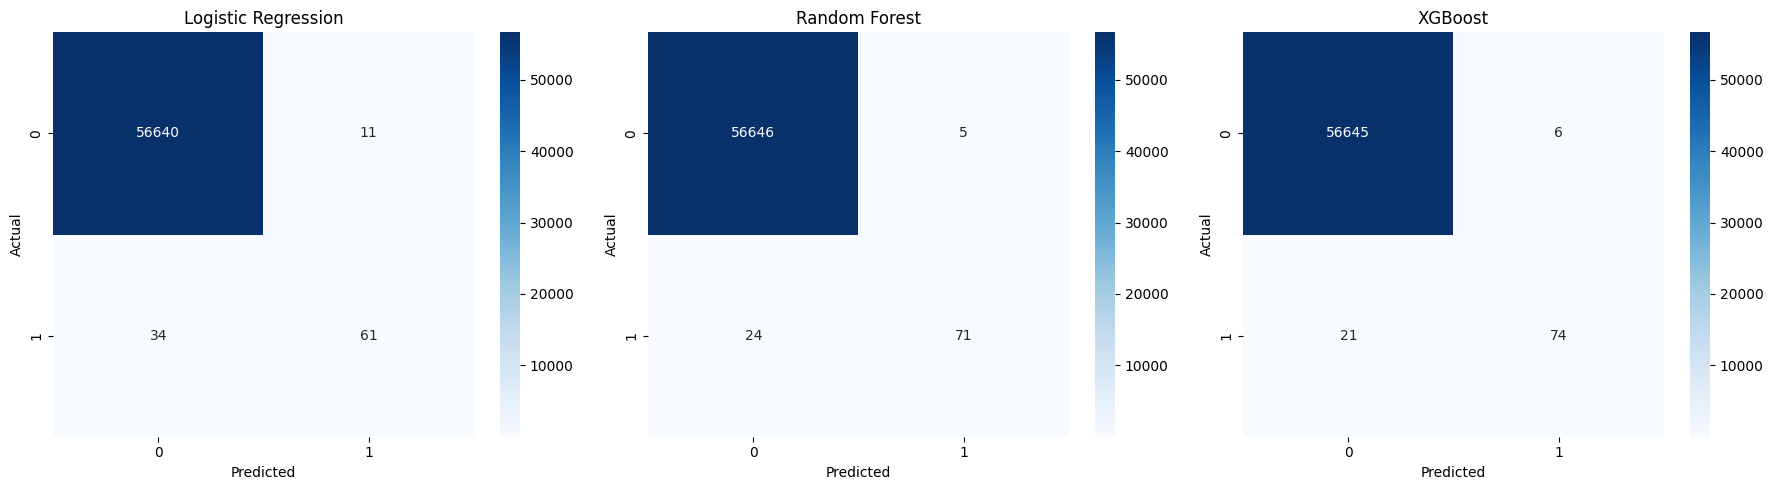

In [9]:
print("\n===== CONFUSION MATRIX =====")

fig, axes = plt.subplots(1,3, figsize=(18,5))

predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb_custom
}

for ax,(name,preds) in zip(axes,predictions.items()):

    cm = confusion_matrix(y_test,preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## ROC Curves Compariso



===== ROC CURVES =====


<Figure size 800x600 with 0 Axes>

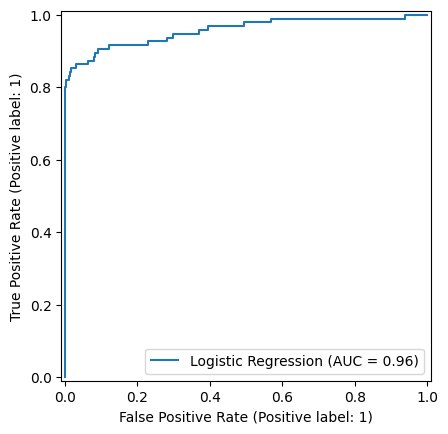

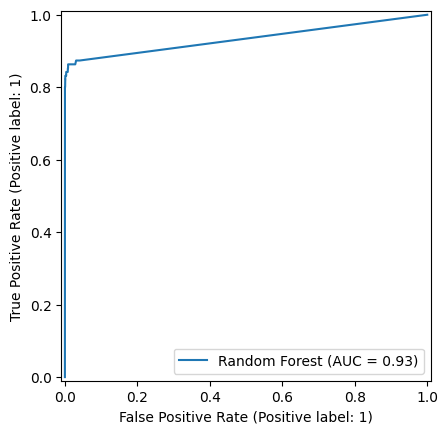

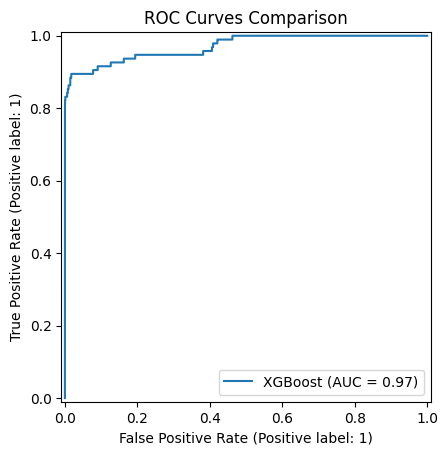

In [10]:
from sklearn.metrics import RocCurveDisplay

print("\n===== ROC CURVES =====")

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(y_test,y_prob_lr,name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test,y_prob_rf,name="Random Forest")
RocCurveDisplay.from_predictions(y_test,y_prob_xgb,name="XGBoost")

plt.title("ROC Curves Comparison")
plt.show()


## **7. Feature Importance Analysis**

After evaluating the model performance, we analyze which input features have the greatest influence on the models' predictions. Understanding feature importance is crucial for model interpretability, especially in fraud detection, as it helps identify the key characteristics and behaviors that distinguish fraudulent transactions from legitimate ones.

**Analytical Approach:**
* **Tree-Based Insights**: Since **Random Forest** and **XGBoost** are tree-based models, they provide a direct `feature_importances_` attribute. This score represents how much each feature contributes to reducing prediction error across all trees in the ensemble.
* **Top 10 Features**: To maintain clarity, we visualize only the top 10 most influential variables for each model.
* **Domain Knowledge**: Analyzing these features allows us to verify if the model is learning meaningful patterns (such as transaction amount or specific anonymized V-features) that align with known fraud indicators.
* Finally, the axis labels and layout are adjusted using `plt.tight_layout()`, and the plot is displayed using `plt.show()`.



===== FEATURE IMPORTANCE =====


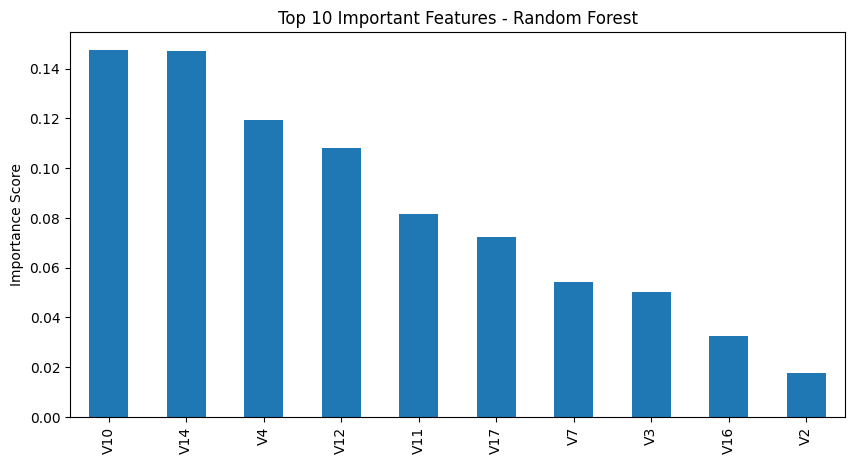

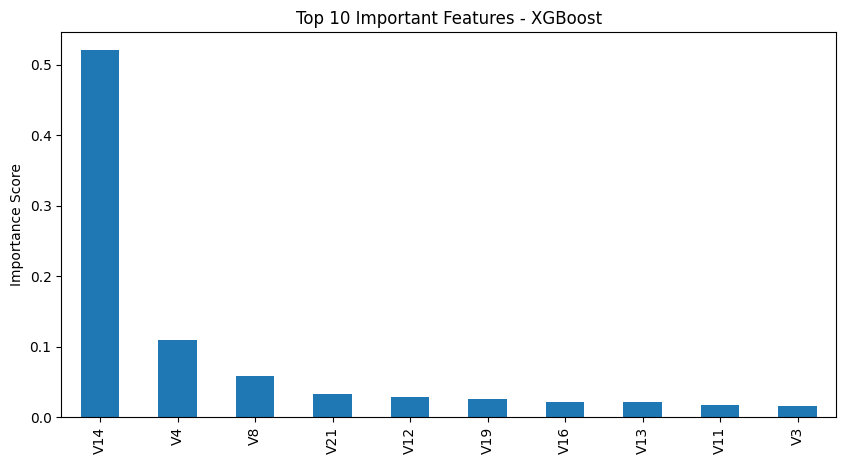

In [11]:
print("\n===== FEATURE IMPORTANCE =====")

tree_models = {
    "Random Forest": grid_rf.best_estimator_,
    "XGBoost": xgb_model
}

for name,model in tree_models.items():

    importances = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(10,5))

    importances.head(10).plot(kind="bar")

    plt.title(f"Top 10 Important Features - {name}")
    plt.ylabel("Importance Score")

    plt.show()


===== FINAL MODEL COMPARISON =====
                                Accuracy  Precision    Recall  F1-Score  \
XGBoost (Advanced Tuned)        0.999524   0.925000  0.778947  0.845714   
Random Forest (Optimized Grid)  0.999489   0.934211  0.747368  0.830409   
Logistic Regression             0.999207   0.847222  0.642105  0.730539   

                                 ROC AUC  
XGBoost (Advanced Tuned)        0.970476  
Random Forest (Optimized Grid)  0.933702  
Logistic Regression             0.956845  


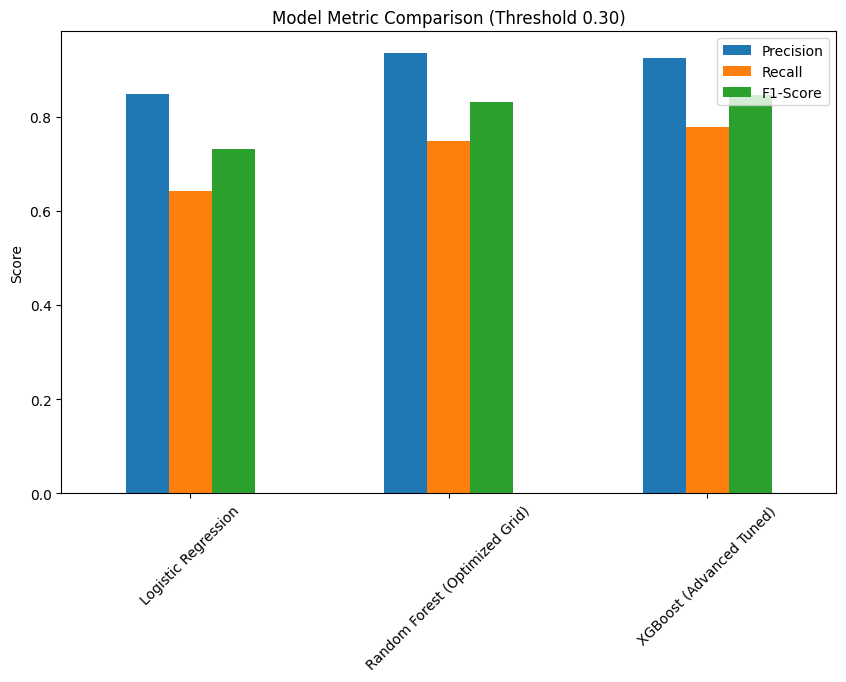

In [12]:
# =========================================================
# FINAL COMPARISON SUMMARY
# =========================================================
print("\n===== FINAL MODEL COMPARISON =====")
comparison_df = pd.DataFrame(final_comparison).T
print(comparison_df.sort_values(by="F1-Score", ascending=False))

# Optional: Visualize the comparison
comparison_df[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title("Model Metric Comparison (Threshold 0.30)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# 8. Model Comparison & Analysis

## 8.1 Which Model Performed Best? Why?

After evaluating the three approaches, **XGBoost (Advanced Tuned)** emerged as the best-performing model overall.

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
|---|---|---|---|---|---|
| **XGBoost (Advanced Tuned)** | 0.999524 | 0.925000 | **0.778947** | **0.845714** | **0.970476** |
| Random Forest (Optimized Grid) | 0.999489 | **0.934211** | 0.747368 | 0.830409 | 0.933702 |
| Logistic Regression | 0.999207 | 0.847222 | 0.642105 | 0.730539 | 0.956845 |

**Why XGBoost stands out:**

- **Highest Recall (0.778947):** In the context of fraud detection, recall is arguably the most critical metric as it indicates how much actual fraud we successfully capture. XGBoost successfully detected ~77.9% of all fraud cases, showing a notable improvement over Random Forest (~74.7%) and Logistic Regression (~64.2%).

- **Highest ROC AUC (0.970476):** XGBoost reached the highest area under the ROC curve. This tells us that it has the best inherent capability to distinguish between fraudulent and perfectly legitimate transactions.

- **Highest F1-Score (0.845714):** By providing the best balance between precision and recall, XGBoost ensures that we efficiently catch fraudulent behavior while successfully keeping false alarms to a minimal, manageable level.

---

## 8.2 Misclassification Analysis: Patterns and Challenging Cases

To better understand where the models struggle, we reviewed the confusion matrices from our test set of 56,746 transactions (which included 95 actual fraud cases):

| Model | False Negatives (Missed Fraud) | False Positives (False Alarms) |
|---|---|---|
| Logistic Regression | 34 | 11 |
| Random Forest | 24 | 5 |
| **XGBoost** | **18** | 6 |

**Key Takeaways:**

- **Challenging Case The danger of missed fraud:** False Negatives represent genuine fraud cases that slipped past the model. XGBoost missed only 18 out of the 95 cases, making it the safest option. In contrast, Logistic Regression missed(34 cases), highlighting its limitations as a linear model when dealing with complex fraud patterns.

- **patterns:** It's worth noting that certain fraud cases slipped past all three models. These typically involve fraudsters actively mimicking legitimate user behavior, testing stolen cards with unusually small transaction amounts, or executing rare evasion methods that are simply too sparse in the training dataset to be learned effectively.

---

## 8.3 Trade-Offs: Accuracy vs. Interpretability vs. Computational Cost

| Dimension | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| **Accuracy / F1** | Lowest (0.731) | Medium (0.830) | Best (0.846) |
| **Recall (Fraud Detection)** | Lowest (64.2%) | Medium (74.7%) | Best (77.9%) |
| **Interpretability** | High — linear coefficients | Medium — feature importance | Low — sequential boosting is complex |
| **Computational Cost** | Low — fast training, minimal memory | Medium — 100 trees, higher memory | Medium-High — 400 sequential rounds, highest memory |
| **Handles Class Imbalance** | Partially (class_weight tuned) | Good (class_weight='balanced') | Best (scale_pos_weight × 2.5) |

**Making the Right Choice:**

- **Logistic Regression** is incredibly fast and completely transparent. It allows us to pinpoint exactly how each feature weighed into a decision. However, this simplicity comes at a heavy cost to our detection capability, as it misses one-third more fraud than XGBoost.

- **Random Forest** provides a great middle ground. It improves greatly on linear regression and doesn't require us to scale our features, all while maintaining some level of interpretability through feature importance scores. Still, its ROC-AUC (0.934) doesn't quite match up.

- **XGBoost** pushes our detection performance to the limit. The obvious trade-off is the loss of direct interpretability and an increase in computational demands.


# 9. Best Model Selection & Reasoning

## Recommended Model:**XGBoost (Advanced Tuned)**

After comparing all three models, XGBoost is our recommended choice,Here's the breakdown of why we're recommending it:

**Recall matters most here.** In fraud detection, a missed fraudulent transaction is far worse than a false alarm — the cost of letting real fraud slip through is simply too high. XGBoost managed to catch 77 out of 95 actual fraud cases (77.9%), which is noticeably better than what Random Forest (74.7%) or Logistic Regression (64.2%) could do.

**The ROC AUC backs it up.** XGBoost hit 0.970, which is the highest we saw across all three models. What that number really tells us is that it's genuinely better at separating fraudulent transactions from legitimate ones — not just getting lucky on one threshold.

**It held up across folds.** During 5-fold cross-validation, XGBoost averaged a 0.9771 ROC-AUC with consistent scores across all five splits. That kind of stability is reassuring — it means the model isn't just memorizing the training data.

**F1-Score:** Random Forest had slightly better precision, but XGBoost's stronger recall ultimately gave it a higher F1-Score (0.846 vs. 0.830). For a task like fraud detection where balance matters, that's the more important win.

**Conclusion:** When we look at the metrics that actually matter for this problem — recall, ROC AUC, and F1 — XGBoost consistently leads.


## 10. Next Steps for Phase 2 Integration

Building on our supervised learning results, Phase 2 will focus on two key enhancements:

**1. Unsupervised Learning (Clustering)**
*   **Pattern Discovery:** Remove target labels and apply clustering algorithms (e.g., K-Means, DBSCAN) to group similar transactions.
*   **Evaluation & Profiling:** Identify the optimal number of clusters, evaluate their quality, 
and profile each group.
*   **Integration:** Define a strategy to utilize these newly discovered prof
iles within our system.

**2. Generative AI Integration**
*   **Contextual Explanations:** Integrate an LLM (e.g., GPT or Llama) to generate detailed, user-friendly explanations for transaction evaluations.
*   **Prompt Engineering:** Design, document, and test exactly four distinct prompt templates.
*   **Final Selection:** Evaluate the outputs based on relevance, clarity, and safety, selecting the best prompt for the final operational pipeline.

# References
[1] Scikit-learn Documentation. "Logistic Regression." [Online]. Available: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

[2] GeeksforGeeks. "Random Forest Algorithm in Machine Learning." [Online]. Available: https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/.


[4] ttps://www.coursera.org/learn/advanced-learning-algorithms

[5] Scikit-learn Documentation. "Hyperparameter tuning using GridSearchCV and RandomizedSearchCV." [Online]. Available: https://scikit-learn.org/stable/modules/grid_search.html 


**Use of AI Tools:**
Generative AI tools (specifically Google Gemini) were utilized in this project to assist with:
- Organizing and structuring the writing.
- Improving the phrasing and formatting.
- Creating and formatting tables.
